In [ ]:
import numpy as np
import matplotlib.pyplot as plt
exp = np.array([1,2,3,4,5]).reshape(-1,1)  ## x (input)
lpa = np.array([11,12,13,14,15])  # y(output)

In [ ]:
## y = mx + c

m = 1
# price = m * sqft + c

c = m * sqft[0] + price[0]
c

np.int64(12)

In [ ]:
price

array([11, 12, 13, 14, 15])

In [ ]:
y_pred = 1 * exp + 10
y_pred

array([[11],
       [12],
       [13],
       [14],
       [15]])

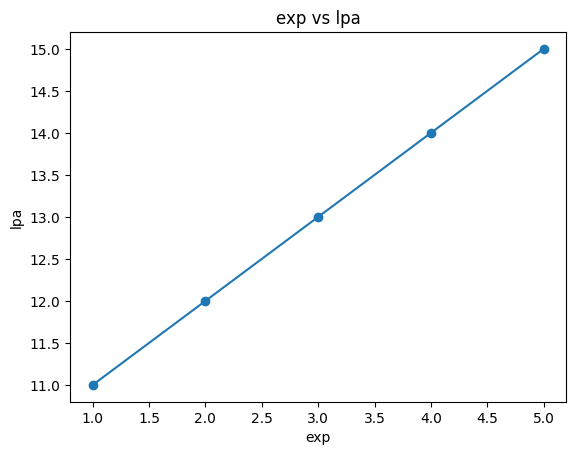

In [ ]:
plt.scatter(exp,lpa)
plt.plot(exp,y_pred)
plt.xlabel("exp")
plt.ylabel("lpa")
plt.title("exp vs lpa");

In [ ]:
1 * 7 + 10

17

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr

LinearRegression()

In [ ]:
lr.fit(exp,lpa)

LinearRegression()

In [ ]:
lpa

array([11, 12, 13, 14, 15])

In [ ]:
y_pred = lr.predict([[17]])
y_pred

array([27.])

In [ ]:
1/ 5 (lpa - pred_lpa) ** 2

In [ ]:
m = lr.coef_
m

array([1.])

In [ ]:
c = lr.intercept_
c

np.float64(10.0)

In [ ]:
y_pred = 1 * 17 + 10
y_pred

27

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/raveendran2862/dataset/refs/heads/main/Real%20estate.csv")
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [ ]:
df.columns = (
    df.columns
    .str.replace(r'^[A-Z]\d+\s', '', regex=True)   # remove X1, X2...
    .str.replace(r'^Y\s', '', regex=True)          # remove Y
    .str.strip()
    .str.replace(' ', '_')
    .str.lower()
)

print(df.columns)

Index(['no', 'transaction_date', 'house_age',
       'distance_to_the_nearest_mrt_station', 'number_of_convenience_stores',
       'latitude', 'longitude', 'house_price_of_unit_area'],
      dtype='object')


In [ ]:
df.columns

Index(['no', 'transaction_date', 'house_age',
       'distance_to_the_nearest_mrt_station', 'number_of_convenience_stores',
       'latitude', 'longitude', 'house_price_of_unit_area'],
      dtype='object')

In [ ]:
df.drop(['no', 'transaction_date'],axis = 1,inplace = True)
df.head()

,house_age,distance_to_the_nearest_mrt_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,32.0,84.87882,10,24.98298,121.54024,37.9
1,19.5,306.59470,9,24.98034,121.53951,42.2
2,13.3,561.98450,5,24.98746,121.54391,47.3
3,13.3,561.98450,5,24.98746,121.54391,54.8
4,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   house_age                            414 non-null    float64
 1   distance_to_the_nearest_mrt_station  414 non-null    float64
 2   number_of_convenience_stores         414 non-null    int64  
 3   latitude                             414 non-null    float64
 4   longitude                            414 non-null    float64
 5   house_price_of_unit_area             414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB


In [ ]:
df.shape

(414, 6)

In [ ]:
df.describe()

,house_age,distance_to_the_nearest_mrt_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


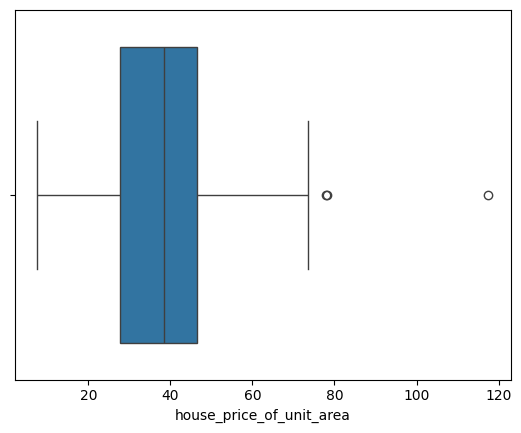

In [ ]:
import seaborn as sns
sns.boxplot(df['house_price_of_unit_area'],orient = "h");

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
x = df.drop('house_price_of_unit_area',axis = 1)
y = df['house_price_of_unit_area']
y

,house_price_of_unit_area
0,37.9
1,42.2
2,47.3
3,54.8
4,43.1
...,...
409,15.4
410,50.0
411,40.6
412,52.5


In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr

LinearRegression()

In [ ]:
lr.fit(x,y)

LinearRegression()

In [ ]:
y_pred = lr.predict(x)
y_pred

array([48.5246244 , 49.15674926, 46.74278224, 46.74278224, 47.79272776,
       33.65488125, 41.2313165 , 45.53084411,  7.84212964, 33.41428306,
       33.7346204 , 52.17000276, 41.86700401, 29.53435032, 44.09077594,
       35.93572764, 50.24037798, 39.04802422, 45.3388434 , 49.86502763,
       33.95398733, 48.11859881, 29.85788923, 48.22616554, 35.5808554 ,
       32.3529296 , 48.67273068, 41.27927269, 40.9035398 , 46.04528471,
       11.73760793, 42.77317343, 32.53977723, 45.91712832, 49.25701687,
       32.43688178, 31.64703194, 30.58396468, 46.8813678 , 45.83648585,
       15.25198859, 14.79783749, 35.03809823, 42.4529739 , 45.42915603,
       40.15390887, 45.46813338, 35.24377701, 11.49130668, 12.23806302,
       40.37391738, 24.13405026, 32.67858223, 41.78632896, 45.86337753,
       24.55494404, 42.06361692, 46.7725273 , 11.99603787, 40.71774414,
       32.60727146, 48.57452744, 30.93045845, 45.45604771, 32.10596259,
       42.25462841, 47.63466421, 45.07948296, 41.91010032, 46.95

In [ ]:
res = y_pred - y
res

,house_price_of_unit_area
0,10.624624
1,6.956749
2,-0.557218
3,-8.057218
4,4.692728
...,...
409,-0.174903
410,2.358245
411,5.792936
412,-7.312950


In [ ]:
from sklearn.metrics import r2_score,mean_squared_error

In [ ]:
r2_score(y,y_pred)

0.5711617064827472